### NK cell Pseudobulk Differential Expression Analysis using DESeq2
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: Age-associated pseudobulk differential expression*

#### Aim
This notebook performs age-associated differential expression analysis on NK cell pseudobulk count matrices using DESeq2.

Pseudobulk samples were generated at the donor-by-cell-type level. For each NK subset, gene expression was modelled as a function of age while adjusting for sex and batch.

*Note: This notebook performs differential expression testing only. Gene set enrichment analysis was performed separately using the DESeq2 output files.*

In [1]:
library(DESeq2)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb



In [ ]:
# Load gene-by-sample pseudobulk count matrix
counts <- read.csv(
  "/scratch/user/s4575250/BIOX7014_Thesis/write/04_DEG/PICA_Batch001-Batch007/nk_pseudobulk_counts_gene_by_sample.csv",
  row.names = 1,
  check.names = FALSE
)

# Load matching pseudobulk sample metadata
meta <- read.csv(
  "/scratch/user/s4575250/BIOX7014_Thesis/write/04_DEG/PICA_Batch001-Batch007/nk_pseudobulk_metadata.csv",
  row.names = 1,
  check.names = FALSE
)

In [ ]:
# Match metadata order to the pseudobulk count matrix
meta <- meta[colnames(counts), ]

stopifnot(all(colnames(counts) == rownames(meta)))

In [ ]:
# Convert metadata variables into appropriate types for DESeq2 modelling
meta$age <- as.numeric(meta$age)
meta$sex <- factor(meta$sex)
meta$batch <- factor(meta$batch)
meta$cell_type <- factor(meta$cell_type)

# quick check
table(meta$cell_type)
summary(meta$age)
table(meta$sex)
table(meta$batch)


    CD56_bright CD16- NK CD56_dim CD16+ KLRC2+ NK        CD56_dim CD16+ NK 
                      16                      106                      128 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.050   3.942   7.150   8.021  12.697  17.030 


Female   Male 
   100    150 


20240530_WGS_20240530_sc_PICA0001-PICA0007 
                                        14 
20240918_WGS_20240924_sc_PICA0008-PICA0032 
                                        39 
20241106_WGS_20241106_sc_PICA0033-PICA0069 
                                        52 
20250114_WGS_20241218_sc_PICA0071-PICA0097 
                                        41 
20250324_WGS_20250324_sc_PICA0098-PICA0118 
                                        30 
20250612_WGS_20250612_sc_PICA0119-PICA0146 
                                        41 
20250814_WGS_20250814_sc_PICA0147-PICA0173 
                                        33 

## DESeq2

In [ ]:
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk", showWarnings = FALSE)

# Define function to run DESeq2 separately for each subset
run_deseq_celltype <- function(ct) {
  
  samples <- rownames(meta)[meta$cell_type == ct]
  
  counts_sub <- counts[, samples, drop = FALSE]
  meta_sub <- meta[samples, , drop = FALSE]
  
  # Skip subsets with insufficient donor-level samples
  if (ncol(counts_sub) < 6) {
    message("Skipping ", ct, ": too few samples")
    return(NULL)
  }
  
  # Remove lowly expressed genes before model fitting
  keep_genes <- rowSums(counts_sub >= 10) >= 3
  counts_sub <- counts_sub[keep_genes, ]
  
  # Construct DESeq2 dataset with batch and sex adjustment
  dds <- DESeqDataSetFromMatrix(
    countData = round(as.matrix(counts_sub)),
    colData = meta_sub,
    design = ~ batch + sex + age
  )
  
  # Fit negative binomial model
  dds <- DESeq(dds)
  
  # Extract age-associated differential expression results
  res <- results(dds, name = "age")
  res <- as.data.frame(res)
  res$gene <- rownames(res)
  res <- res[order(res$padj), ]
  
  # Create safe cell-type name for file export
  safe_ct <- gsub("[ /+]", "_", ct)
  
  # Save full DESeq2 result table
  write.csv(
    res,
    paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/DESeq2_age_", safe_ct, ".csv"),
    row.names = FALSE
  )
  
  sig <- res[!is.na(res$padj) & res$padj < 0.05, ]
  
  # Save significant age-associated genes
  write.csv(
    sig,
    paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/DESeq2_age_", safe_ct, "_significant.csv"),
    row.names = FALSE
  )
  
  return(res)
}

# Run DESeq2 analysis across all subsets
celltypes <- levels(meta$cell_type)

all_deg <- list()

for (ct in celltypes) {
  all_deg[[ct]] <- run_deseq_celltype(ct)
}

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

factor levels were dropped which had no samples

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column nam

In [ ]:
# Create summary table of significant age-associated genes per subset
summary_list <- list()

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) {
    summary_list[[ct]] <- data.frame(
      cell_type = ct,
      n_sig = NA,
      n_up_with_age = NA,
      n_down_with_age = NA
    )
  } else {
    sig <- res[!is.na(res$padj) & res$padj < 0.05, ]
    
    summary_list[[ct]] <- data.frame(
      cell_type = ct,
      n_sig = nrow(sig),
      n_up_with_age = sum(sig$log2FoldChange > 0),
      n_down_with_age = sum(sig$log2FoldChange < 0)
    )
  }
}

# Combine and save DEG summary table
deg_summary <- do.call(rbind, summary_list)

write.csv(
  deg_summary,
  "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/DESeq2_age_summary.csv",
  row.names = FALSE
)

deg_summary

,cell_type,n_sig,n_up_with_age,n_down_with_age
,<chr>,<int>,<int>,<int>
CD56_bright CD16- NK,CD56_bright CD16- NK,11,0,11
CD56_dim CD16+ KLRC2+ NK,CD56_dim CD16+ KLRC2+ NK,114,71,43
CD56_dim CD16+ NK,CD56_dim CD16+ NK,2692,1519,1173


In [7]:
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/top_genes", showWarnings = FALSE, recursive = TRUE)
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/volcano_plots", showWarnings = FALSE, recursive = TRUE)
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/heatmaps", showWarnings = FALSE, recursive = TRUE)

In [ ]:
# Export top 20 age-associated genes for each subset
for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  res <- res[!is.na(res$padj), ]
  res <- res[order(res$padj), ]
  
  top20 <- head(res, 20)
  
  safe_ct <- gsub("[ /+]", "_", ct)
  
  write.csv(
    top20,
    paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/top_genes/top20_DEGs_", safe_ct, ".csv"),
    row.names = FALSE
  )
}

# View top genes for key subsets
head(all_deg[["CD56_bright CD16- NK"]][order(all_deg[["CD56_bright CD16- NK"]]$padj), ], 20)
head(all_deg[["CD56_dim CD16+ KLRC2+ NK"]][order(all_deg[["CD56_dim CD16+ KLRC2+ NK"]]$padj), ], 20)
head(all_deg[["CD56_dim CD16+ NK"]][order(all_deg[["CD56_dim CD16+ NK"]]$padj), ], 20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
IKZF1,106.08415,-0.11105832,0.02362171,-4.701536,2.582111e-06,0.005066102,IKZF1
DIP2A,73.87228,-0.15680117,0.03494975,-4.486475,7.241131e-06,0.007103550,DIP2A
TXNIP,414.58679,-0.16431387,0.03735926,-4.398210,1.091474e-05,0.007138239,TXNIP
FKBP5,23.01930,-0.45812196,0.10638564,-4.306239,1.660539e-05,0.008144944,FKBP5
ITGAX,37.88025,-0.14456278,0.03604184,-4.010972,6.046939e-05,0.023728187,ITGAX
IL32,88.47423,-0.22979883,0.05913707,-3.885868,1.019649e-04,0.033342511,IL32
ERAP2,24.93108,-0.16253037,0.04345704,-3.740024,1.840030e-04,0.038935278,ERAP2
ENSG00000289901,244.78462,-0.10678822,0.02863992,-3.728650,1.925085e-04,0.038935278,ENSG00000289901
GZMH,89.51796,-0.11987183,0.03221508,-3.720985,1.984469e-04,0.038935278,GZMH


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
KIF21A,21.484507,0.10057561,0.014442230,6.963994,3.307582e-12,4.208898e-08,KIF21A
MEGF9,23.714838,0.04515346,0.007798583,5.789957,7.040444e-09,4.038297e-05,MEGF9
SIGLEC17P,36.720082,0.06635139,0.011561376,5.739057,9.520542e-09,4.038297e-05,SIGLEC17P
LINC01684,10.620774,0.10260576,0.018222833,5.630615,1.795682e-08,5.712514e-05,LINC01684
AGAP1,15.864100,0.10137951,0.018860390,5.375260,7.647213e-08,1.837113e-04,AGAP1
NR3C2,4.903304,0.14681496,0.027435841,5.351211,8.736781e-08,1.837113e-04,NR3C2
SELENOM,5.276753,0.09603363,0.018035132,5.324809,1.010593e-07,1.837113e-04,SELENOM
PTGDS,15.880091,0.20423805,0.039596318,5.158006,2.495934e-07,3.970095e-04,PTGDS
GPR141,38.722929,0.09980245,0.020149276,4.953153,7.302048e-07,1.032428e-03,GPR141


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
NR3C2,49.082711,0.12807875,0.012171476,10.522861,6.778343e-26,1.175907e-21,NR3C2
RADX,44.291545,0.12012536,0.011827872,10.156126,3.111965e-24,2.699318e-20,RADX
SELENOM,60.886212,0.12317774,0.012221359,10.078890,6.849551e-24,3.960867e-20,SELENOM
KIF21A,323.634848,0.13893970,0.014631071,9.496208,2.176731e-21,9.440482e-18,KIF21A
MEGF9,445.739274,0.04184455,0.004456797,9.388929,6.061329e-21,2.103039e-17,MEGF9
MID2,7.466805,0.18012082,0.019422115,9.274006,1.792825e-20,5.183655e-17,MID2
NAP1L2,20.734733,0.11394031,0.013062228,8.722885,2.712016e-18,6.721151e-15,NAP1L2
DMTN,19.572119,0.11094478,0.012770372,8.687670,3.699481e-18,8.022324e-15,DMTN
LARGE1,30.896057,0.13616831,0.015813631,8.610819,7.254052e-18,1.398259e-14,LARGE1


In [ ]:
# Combine top 20 age-associated genes from each subset into a single table
combined_top_list <- list()

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  res <- res[!is.na(res$padj), ]
  res <- res[order(res$padj), ]
  
  top20 <- head(res, 20)
  top20$cell_type <- ct
  
  combined_top_list[[ct]] <- top20
}

combined_top_degs <- do.call(rbind, combined_top_list)

write.csv(
  combined_top_degs,
  "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/nk_combined_top20_DEGs_by_celltype.csv",
  row.names = FALSE
)

combined_top_degs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,cell_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CD56_bright CD16- NK.IKZF1,106.084151,-0.11105832,0.023621707,-4.701536,2.582111e-06,5.066102e-03,IKZF1,CD56_bright CD16- NK
CD56_bright CD16- NK.DIP2A,73.872276,-0.15680117,0.034949750,-4.486475,7.241131e-06,7.103550e-03,DIP2A,CD56_bright CD16- NK
CD56_bright CD16- NK.TXNIP,414.586790,-0.16431387,0.037359261,-4.398210,1.091474e-05,7.138239e-03,TXNIP,CD56_bright CD16- NK
CD56_bright CD16- NK.FKBP5,23.019299,-0.45812196,0.106385640,-4.306239,1.660539e-05,8.144944e-03,FKBP5,CD56_bright CD16- NK
CD56_bright CD16- NK.ITGAX,37.880251,-0.14456278,0.036041836,-4.010972,6.046939e-05,2.372819e-02,ITGAX,CD56_bright CD16- NK
CD56_bright CD16- NK.IL32,88.474227,-0.22979883,0.059137065,-3.885868,1.019649e-04,3.334251e-02,IL32,CD56_bright CD16- NK
CD56_bright CD16- NK.ERAP2,24.931082,-0.16253037,0.043457043,-3.740024,1.840030e-04,3.893528e-02,ERAP2,CD56_bright CD16- NK
CD56_bright CD16- NK.ENSG00000289901,244.784624,-0.10678822,0.028639918,-3.728650,1.925085e-04,3.893528e-02,ENSG00000289901,CD56_bright CD16- NK
CD56_bright CD16- NK.GZMH,89.517963,-0.11987183,0.032215075,-3.720985,1.984469e-04,3.893528e-02,GZMH,CD56_bright CD16- NK


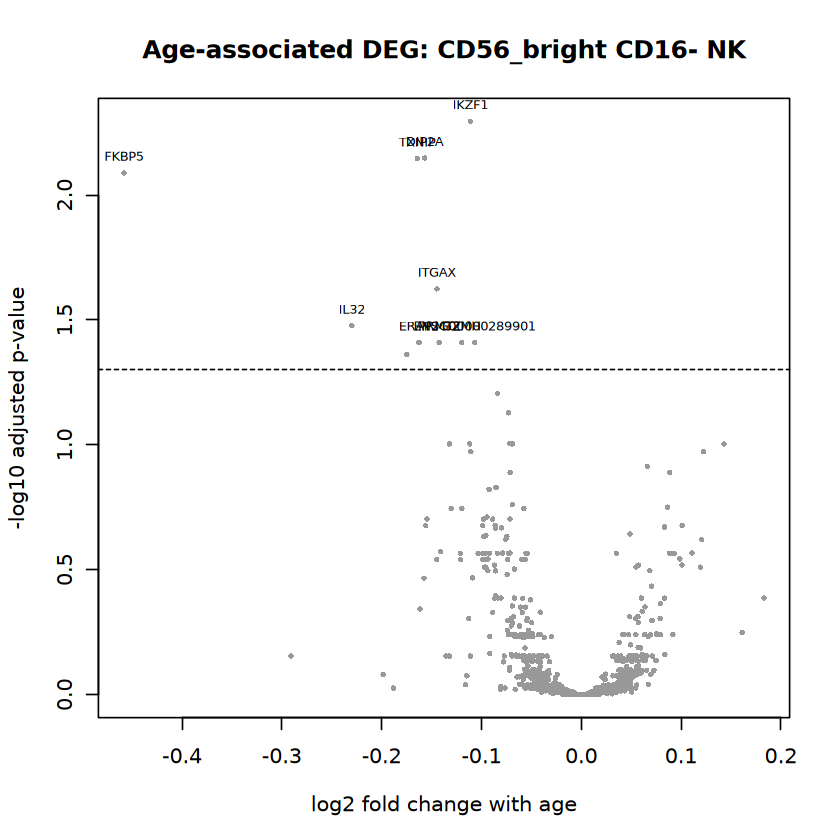

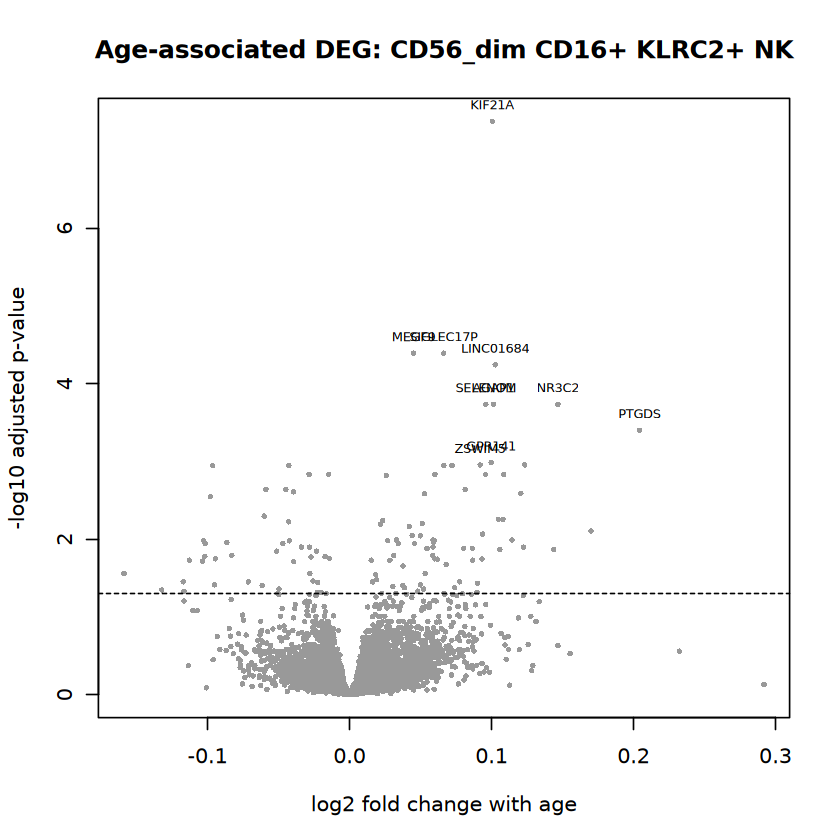

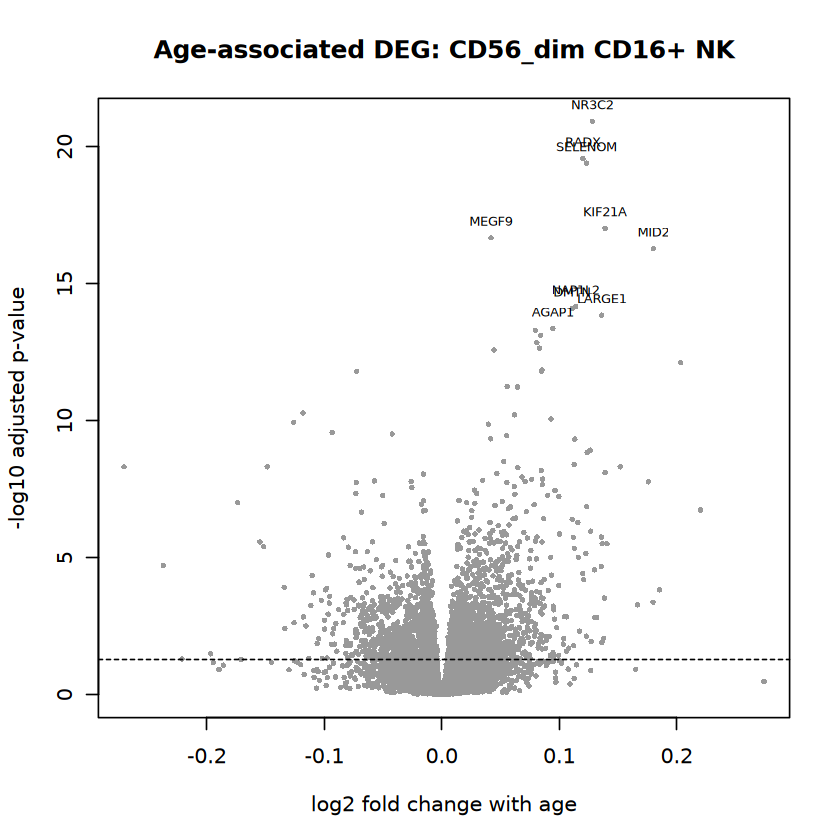

In [ ]:
# Define function to visualise age-associated differential expression results
plot_volcano <- function(res, celltype_name, padj_cutoff = 0.05, lfc_cutoff = 0.5, save_plot = TRUE) {
  
  # Remove genes without adjusted p-values
  res <- res[!is.na(res$padj), ]
  
  # Calculate transformed significance and label genes passing thresholds
  res$neg_log10_padj <- -log10(res$padj)
  res$significant <- res$padj < padj_cutoff & abs(res$log2FoldChange) > lfc_cutoff
  
  # Select top genes for labelling
  top_genes <- head(res[order(res$padj), ], 10)
  
  # Display volcano plot
  plot(
    res$log2FoldChange,
    res$neg_log10_padj,
    pch = 16,
    cex = 0.5,
    col = ifelse(res$significant, "red", "grey60"),
    xlab = "log2 fold change with age",
    ylab = "-log10 adjusted p-value",
    main = paste("Age-associated DEG:", celltype_name)
  )
  
  abline(v = c(-lfc_cutoff, lfc_cutoff), lty = 2, col = "black")
  abline(h = -log10(padj_cutoff), lty = 2, col = "black")
  
  # Label top-ranked genes
  text(
    top_genes$log2FoldChange,
    top_genes$neg_log10_padj,
    labels = top_genes$gene,
    pos = 3,
    cex = 0.6
  )
  
  # Save
  if (save_plot) {
    
    safe_ct <- gsub("[ /+]", "_", celltype_name)
    
    png(
      paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/volcano_plots/volcano_", safe_ct, ".png"),
      width = 1800,
      height = 1500,
      res = 200
    )
    
    plot(
      res$log2FoldChange,
      res$neg_log10_padj,
      pch = 16,
      cex = 0.5,
      col = ifelse(res$significant, "red", "grey60"),
      xlab = "log2 fold change with age",
      ylab = "-log10 adjusted p-value",
      main = paste("Age-associated DEG:", celltype_name)
    )
    
    # Add fold-change and adjusted p-value cutoffs
    abline(v = c(-lfc_cutoff, lfc_cutoff), lty = 2, col = "black")
    abline(h = -log10(padj_cutoff), lty = 2, col = "black")
    
    text(
      top_genes$log2FoldChange,
      top_genes$neg_log10_padj,
      labels = top_genes$gene,
      pos = 3,
      cex = 0.6
    )
    
    dev.off()
  }
}

# Generate volcano plots for each subset
for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  plot_volcano(res, ct)
}

Making heatmap for: CD56_bright CD16- NK

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

factor levels were dropped which had no samples

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

Making heatmap for: CD56_dim CD16+ KLRC2+ NK

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigge

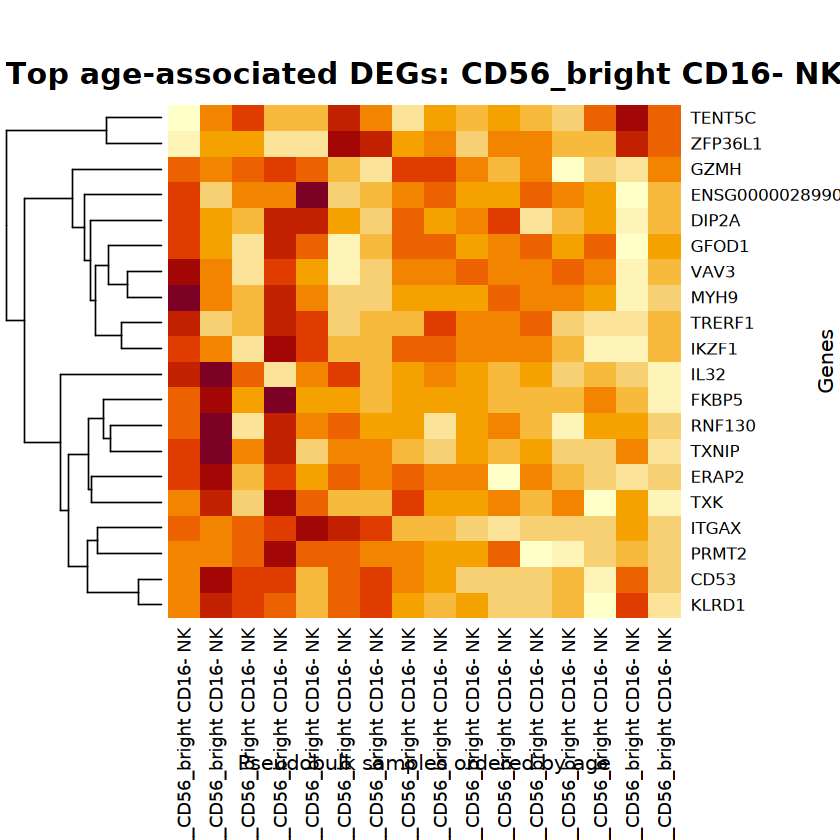

Making heatmap for: CD56_dim CD16+ NK

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



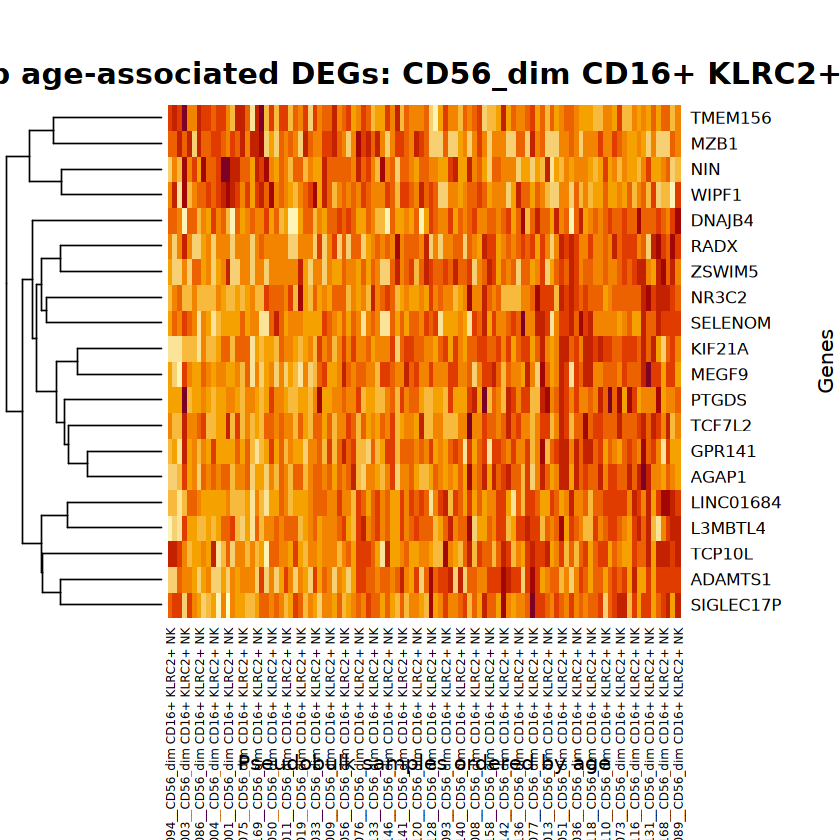

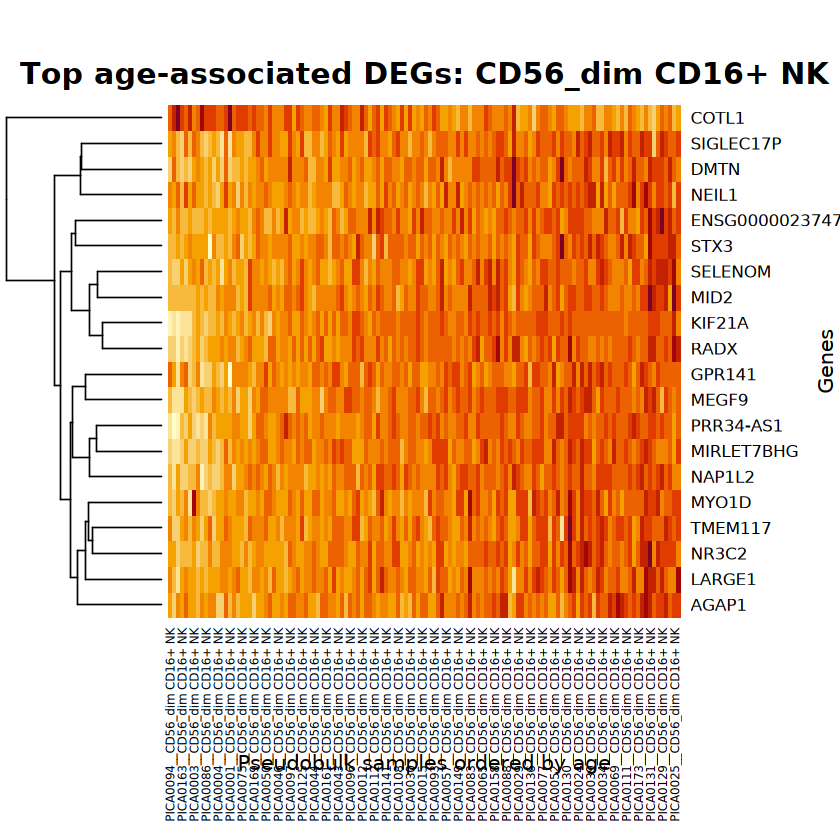

In [ ]:
# Define function to visualise top age-associated genes across pseudobulk samples
make_heatmap <- function(ct, top_n = 20, save_plot = TRUE) {
  
  message("Making heatmap for: ", ct)
  
  # Extract DESeq2 results for selected cell type
  res <- all_deg[[ct]]
  
  if (is.null(res)) {
    message("No DEG result for: ", ct)
    return(NULL)
  }
  
  # Select top-ranked genes by adjusted p-value
  res <- res[!is.na(res$padj), ]
  res <- res[order(res$padj), ]
  
  top_genes <- head(res$gene, top_n)
  
  # Extract pseudobulk counts and metadata for selected cell type
  samples <- rownames(meta)[meta$cell_type == ct]
  
  counts_sub <- counts[, samples, drop = FALSE]
  meta_sub <- meta[samples, , drop = FALSE]
  
  # Apply the same low-expression filter used during DESeq2 modelling
  keep_genes <- rowSums(counts_sub >= 10) >= 3
  counts_sub <- counts_sub[keep_genes, ]
  
  # Retain top genes available in the filtered count matrix
  top_genes <- top_genes[top_genes %in% rownames(counts_sub)]
  
  if (length(top_genes) < 2) {
    message("Too few top genes available for heatmap: ", ct)
    return(NULL)
  }
  
  # Build DESeq2 object for variance-stabilising transformation
  dds <- DESeqDataSetFromMatrix(
    countData = round(as.matrix(counts_sub)),
    colData = meta_sub,
    design = ~ batch + sex + age
  )
  
  vsd <- vst(dds, blind = TRUE)
  
  # Extract transformed expression for top genes
  mat <- assay(vsd)[top_genes, , drop = FALSE]
  
  # z-score per gene
  mat_scaled <- t(scale(t(mat)))
  
  # order samples by age
  sample_order <- order(meta_sub$age)
  mat_scaled <- mat_scaled[, sample_order, drop = FALSE]
  
  # Display heatmap
  heatmap(
    mat_scaled,
    Colv = NA,
    scale = "none",
    margins = c(8, 8),
    main = paste("Top age-associated DEGs:", ct),
    xlab = "Pseudobulk samples ordered by age",
    ylab = "Genes"
  )
  
  # Save
  if (save_plot) {
    
    safe_ct <- gsub("[ /+]", "_", ct)
    
    png(
      paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/heatmaps/heatmap_top", top_n, "_", safe_ct, ".png"),
      width = 2000,
      height = 1600,
      res = 200
    )
    
    heatmap(
      mat_scaled,
      Colv = NA,
      scale = "none",
      margins = c(8, 8),
      main = paste("Top age-associated DEGs:", ct),
      xlab = "Pseudobulk samples ordered by age",
      ylab = "Genes"
    )
    
    dev.off()
  }
}

# Generate heatmaps for each subset
for (ct in names(all_deg)) {
  make_heatmap(ct, top_n = 20)
}

In [ ]:
# Summarise Marker Gene Differential Expression
# Define marker genes used for biological interpretation of subset states
marker_genes <- c(
  # Core NK
  "NKG7", "GNLY", "KLRD1", "NCAM1",

  # Cytotoxicity
  "PRF1", "GZMB", "GZMH", "CTSW",

  # Mature / adaptive NK
  "FCGR3A", "CX3CR1", "FGFBP2", "KLRC1", "KLRC2",

  # Activation / inhibitory receptors
  "TIGIT", "HAVCR2", "LAG3",

  # Interferon response
  "ISG15", "IFIT1", "IFIT3", "MX1",

  # Proliferation
  "MKI67", "TOP2A"            
)

# Extract DESeq2 results for selected marker genes across subsets
marker_summary_list <- list()

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  sub <- res[res$gene %in% marker_genes, ]
  sub$cell_type <- ct
  
  marker_summary_list[[ct]] <- sub
}

marker_summary <- do.call(rbind, marker_summary_list)

write.csv(
  marker_summary,
  "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/nk/nk_marker_gene_DEG_summary.csv",
  row.names = FALSE
)

marker_summary

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,cell_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CD56_bright CD16- NK.GZMH,89.517963,-0.119871827,0.032215075,-3.72098544,0.0001984469,0.038935278,GZMH,CD56_bright CD16- NK
CD56_bright CD16- NK.KLRD1,139.318564,-0.071467754,0.021099584,-3.38716412,0.0007061913,0.098967663,KLRD1,CD56_bright CD16- NK
CD56_bright CD16- NK.GZMB,218.357309,-0.059334856,0.023314039,-2.54502683,0.0109269341,0.287855836,GZMB,CD56_bright CD16- NK
CD56_bright CD16- NK.KLRC2,50.317566,-0.161551767,0.071962226,-2.24495232,0.0247711933,0.454215713,KLRC2,CD56_bright CD16- NK
CD56_bright CD16- NK.CTSW,182.325690,-0.049720729,0.023235656,-2.13984619,0.0323671989,0.515242919,CTSW,CD56_bright CD16- NK
CD56_bright CD16- NK.KLRC1,64.780885,-0.076416823,0.069003119,-1.10744012,0.2681036891,0.940849575,KLRC1,CD56_bright CD16- NK
CD56_bright CD16- NK.FCGR3A,79.994902,-0.018141843,0.032519707,-0.55787227,0.5769316094,0.975902590,FCGR3A,CD56_bright CD16- NK
CD56_bright CD16- NK.FGFBP2,93.242807,-0.022409135,0.041729563,-0.53700861,0.5912616681,0.975902590,FGFBP2,CD56_bright CD16- NK
CD56_bright CD16- NK.PRF1,180.172350,-0.012847761,0.025776981,-0.49841992,0.6181880970,0.975902590,PRF1,CD56_bright CD16- NK
